In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import os
from statsmodels.formula.api import ols

os.chdir('/Users/lior/DS6021/DS6021_F26/data')

df = pd.read_csv('DS6021-Fall26-Anonymized-cleaned.csv')
#
years_col = 'How many years ago did you receive your undergraduate degree?'
sleep_col = 'How many hours do you sleep in a typical night?'
df = df.rename(columns={years_col: 'years_since_ug', sleep_col: 'sleep_hours'})

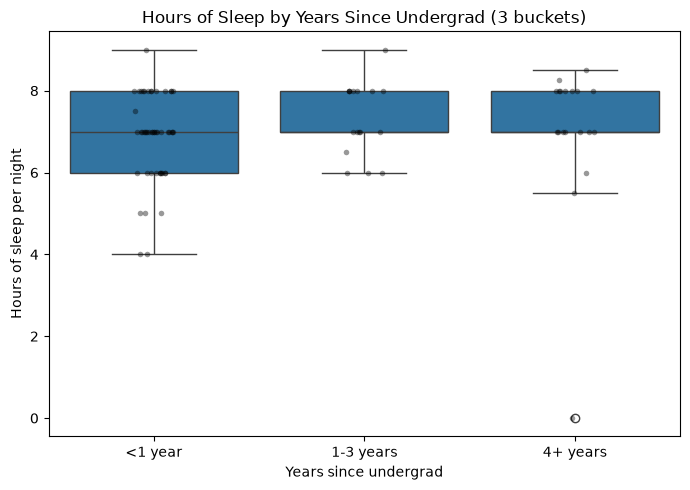

In [4]:
#Q1

rebin_map = {
    '< 1 Year':'<1 year',
    '1-3 Years':'1-3 years',
    '4-6 Years':'4+ years',
    '7-10 Years': '4+ years',
    '10+ Years':'4+ years',
}
df['years_bucket3'] = df['years_since_ug'].map(rebin_map)
order3 = ['<1 year', '1-3 years', '4+ years']
df['years_bucket3'] = pd.Categorical(df['years_bucket3'], categories=order3, ordered=True)

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='years_bucket3', y='sleep_hours', order=order3)
sns.stripplot(data=df, x='years_bucket3', y='sleep_hours', order=order3, color='black', alpha=0.4, size=4) #cleaned with claude
plt.title('Hours of Sleep by Years Since Undergrad (3 buckets)')
plt.xlabel('Years since undergrad')
plt.ylabel('Hours of sleep per night')
plt.tight_layout()
plt.show()

Levene's test: stat = 0.5643, p = 0.5709
ANOVA: F = 0.8245, p = 0.4420
                      sum_sq    df         F   PR(>F)
C(years_bucket3)    2.621161   2.0  0.824484  0.44202
Residual          131.934799  83.0       NaN      NaN
Shapiro-Wilk on residuals: stat = 0.8166, p = 0.0000
<1 year: Shapiro stat=0.8913, p=0.0003, n=50
1-3 years: Shapiro stat=0.8853, p=0.0387, n=17
4+ years: Shapiro stat=0.6036, p=0.0000, n=19


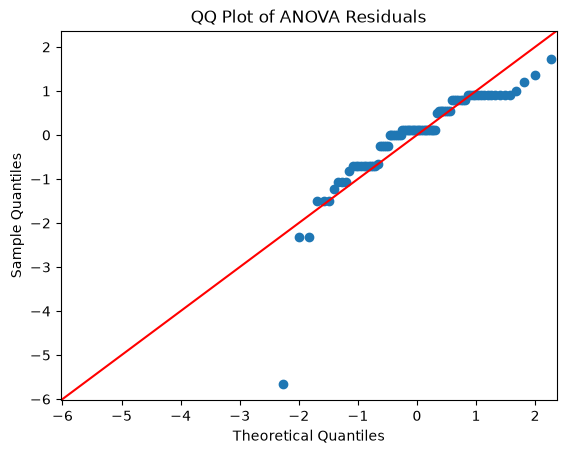

In [5]:
#Q2
groups = [g['sleep_hours'].values for _, g in df.groupby('years_bucket3', observed=True)]
levene_stat, levene_p = stats.levene(*groups)
print(f"Levene's test: stat = {levene_stat:.4f}, p = {levene_p:.4f}")
f_stat, anova_p = stats.f_oneway(*groups)
print(f"ANOVA: F = {f_stat:.4f}, p = {anova_p:.4f}")

model = ols('sleep_hours ~ C(years_bucket3)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
resid = model.resid
shapiro_stat, shapiro_p = stats.shapiro(resid)
print(f"Shapiro-Wilk on residuals: stat = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")

for name, g in df.groupby('years_bucket3', observed=True):
    s, p = stats.shapiro(g['sleep_hours'])
    print(f"{name}: Shapiro stat={s:.4f}, p={p:.4f}, n={len(g)}")
sm.qqplot(resid, line='45', fit=True)
plt.title('QQ Plot of ANOVA Residuals')
plt.show()

The assumption isnt violated because the residuals gives p=0.0000 and each group fails normality, mostly because someone reported that they get 0 hours of sleep (???) shown in the first plot.

Q3

a. The original brackets are more categorical when they need to be treated as a continuous variable. It seems like its a little innacurate since its a range and not an exact value. If you pick the range of 7-10 years, there can be anyone that is at 7, 8, or 9 years out of undergrad, but the survey just puts all of them into one group. 

b. Not really, it doesnt really affect the survey design but it might make the statistical aspect a little better. 3 buckets can be a little more balanced since there wouldnt be as many buckets with small groups, but it doesnt change the survey design in any way.

c. Asking for a solid number instead of a range would make it a lot more accurate and wouldnt generalize the survey results as much. Making it a dropdown answer with a specific number will make it so that we can avoid rounding numbers and takes out the influence it has on the conclusions we draw in the end.





Q4

This survey isnt exactly the best dataset when it comes to learning aboiut what a good survey should look like. It was a good tool to use when it comes to practicing how to load data, but its weak when it comes to answering our questions. The sample size was small and was collected from a group of mostly STEM majors which I feel like makes the survey a little biased as opposed to a random sample. The questions are also pretty subjective, some people may be just be over/underestimating. For example, the one person who typed in 0 might genuinely just have done that as a joke or was trying to exaggerate how little sleep they get. The ranges also just discard and guesses info instead of having an exact numberical value. 
